# Módulo 2 — Modelo neoclásico: SCB, Galí BQ e iteración de valor

**Curso complementario · puremacro · mazo Slides02 — el modelo neoclásico (semanas 3–4)**

### Objetivos de aprendizaje
Al terminar esta lección podrás:
1. Entender la **prueba empírica** del modelo neoclásico: ¿los choques
   tecnológicos generan los ciclos, como sostiene el RBC?
2. Identificar un **choque tecnológico** con la restricción de largo plazo de
   **Blanchard–Quah** y replicar el resultado de **Galí (1999)**: las horas
   trabajadas *caen* en impacto.
3. Ver por qué el hallazgo depende de una decisión de especificación
   (diferencias vs. niveles) — la crítica de **CEV (2003)**.
4. Calcular el largo plazo del modelo —estado estacionario y **senda de
   crecimiento balanceado (SCB)**— y resolver los **coeficientes
   indeterminados** $(\psi_k,\psi_c,\psi_l)$ de la log-linealización.
5. Resolver el modelo de crecimiento por **iteración de la función de valor**
   (VFI) y contrastarlo con la **solución exacta de Brock–Mirman** ($\delta=1$).
6. Ver que el operador de Bellman es una **contracción**: el error cae
   geométricamente a tasa $\log\beta$.

Todo corre en Python puro sobre tu **instalación local** de `puremacro`
(`pip install puremacro`), con los datos congelados del *bundle*: sin conexión y sin costo.

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib
try:  # bajo Jupyter/ipykernel: conserva el backend inline (captura figuras)
    get_ipython()
except NameError:
    matplotlib.use("Agg")  # script plano / CLI: backend no interactivo
import matplotlib.pyplot as plt
_cwd = pathlib.Path.cwd()
_nb = _cwd if (_cwd / "_nbstyle.py").exists() else _cwd.parent
sys.path.insert(0, str(_nb)); sys.path.insert(0, str(_nb / "course"))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor
DATA = (_nb / "course" / "data")

## 1. La prueba empírica del modelo neoclásico

El modelo neoclásico estocástico (RBC) sostiene que los **choques a la
productividad** ($A_t$) son el motor del ciclo económico. Una predicción nítida
de la versión canónica con oferta laboral: tras una mejora tecnológica
**positiva**, tanto el producto como las **horas trabajadas** deberían *subir*.

**Galí (1999)** puso a prueba justo esta predicción. Su hallazgo fue incómodo
para el RBC: ante un choque tecnológico positivo, las horas **caen** en impacto.
Si la tecnología fuera el motor del ciclo, el modelo RBC básico no reproduce
el comovimiento observado.

### Identificación de largo plazo (Blanchard–Quah)

¿Cómo aislar el choque *tecnológico* de otros choques (de demanda, de política)?
**Blanchard–Quah (1989)** proponen una restricción de **largo plazo**: en un VAR
bivariado de $(\Delta\log\text{productividad},\ \text{horas})$, solo el choque
tecnológico puede mover la **productividad laboral** de forma permanente. Los
demás choques tienen efecto de largo plazo **nulo** sobre la productividad.

Esa única restricción basta para recuperar la matriz de impacto y, con ella, la
**función impulso-respuesta** de las horas al choque tecnológico.

`puremacro` implementa esta identificación en NumPy puro:
`bq_svar(Y, p=..., horizon=..., permanent_var_idx=0, n_boot=..., seed=...)`
devuelve un `BQSVARResult` con `irf_point`, `irf_lower`, `irf_upper` (IRFs
**acumuladas** a lo largo del horizonte). Todos los argumentos salvo `Y` son
**por palabra clave**, y las IRFs son la respuesta a un choque de **una
desviación estándar**, no a un choque unitario. La receta completa está en
`puremacro/examples/gali_1999_hours.py`.

## 2. Replicando a Galí con datos reales de EE. UU.

Cargamos un corte congelado de FRED (`gali1999.csv` del bundle):
`ophnfb` (productividad laboral, producto por hora), `hoanbs` (horas) y
`cnp16ov` (población). Construimos:

- $\Delta\text{prod} = 100\cdot\Delta\log(\texttt{ophnfb})$
- $h = 100\cdot\log(\texttt{hoanbs}/\texttt{cnp16ov})$, demediado (horas per cápita)
- $\Delta h = $ primera diferencia de $h$

y estimamos **dos** VAR: horas en **diferencias** (Galí) y en **niveles** (CEV).

In [2]:
from puremacro.var.identify.bq import bq_svar

d = pd.read_csv(DATA / "gali1999.csv")
d["date"] = pd.to_datetime(d["date"]); d = d.set_index("date").sort_index()
dprod = 100.0 * np.log(d["ophnfb"]).diff()
h = 100.0 * np.log(d["hoanbs"] / d["cnp16ov"]); h = h - h.mean()
panel = pd.concat({"dprod": dprod, "h": h, "dh": h.diff()}, axis=1).dropna()
panel = panel.loc[:"2007-12-31"]                     # muestra estándar pre-Gran Recesión

Y_diff = panel[["dprod", "dh"]].to_numpy()           # horas en diferencias (Galí)
Y_lvl = panel[["dprod", "h"]].to_numpy()             # horas en niveles (CEV)

res_diff = bq_svar(Y_diff, p=4, horizon=12, permanent_var_idx=0, n_boot=200, seed=0)
res_lvl = bq_svar(Y_lvl, p=4, horizon=12, permanent_var_idx=0, n_boot=200, seed=0)

print(f"muestra: {panel.index.min().date()} .. {panel.index.max().date()} "
      f"({len(panel)} trimestres)")

muestra: 1948-04-01 .. 2007-10-01 (239 trimestres)


### Respuesta de las horas al choque tecnológico

`bq_svar` **acumula** las IRFs, así que en la especificación en diferencias la
respuesta acumulada de las horas *es* la respuesta en nivel. En la
especificación en niveles hay que **des-acumular** (`np.diff`) para leer la
respuesta en nivel. El índice `irf_point[h, i, j]` es la respuesta de la
variable `i` al choque `j` en el horizonte `h`; aquí `i=1` (horas), `j=0`
(choque tecnológico permanente).

In [3]:
impact_diff = float(res_diff.irf_point[0, 1, 0])                 # horas en diferencias, h=0
n = res_lvl.irf_point.shape[1]
raw_lvl = np.diff(res_lvl.irf_point, axis=0, prepend=np.zeros((1, n, n)))
impact_lvl = float(raw_lvl[0, 1, 0])                            # horas en niveles, h=0
lr_prod = float(res_diff.irf_point[-1, 0, 0])                   # efecto de largo plazo en productividad

print("choque tecnológico de UNA desviación estándar:")
print(f"  efecto de largo plazo en productividad: {lr_prod:+.3f}%")
print(f"  impacto en horas, DIFERENCIAS (Galí): {impact_diff:+.3f}%  "
      f"[banda 90%: {res_diff.irf_lower[0,1,0]:+.3f}, {res_diff.irf_upper[0,1,0]:+.3f}]")
print(f"  impacto en horas, NIVELES (CEV):      {impact_lvl:+.3f}%")

assert lr_prod > 0.0                        # el choque identificado es POSITIVO
assert impact_diff < 0.0                    # Galí: las horas CAEN en impacto
assert res_diff.irf_upper[0, 1, 0] < 0.0    # la banda al 90% excluye el cero
assert impact_lvl > 0.0                     # en niveles el signo se VOLTEA (CEV)

choque tecnológico de UNA desviación estándar:
  efecto de largo plazo en productividad: +0.750%
  impacto en horas, DIFERENCIAS (Galí): -0.243%  [banda 90%: -0.382, -0.065]
  impacto en horas, NIVELES (CEV):      +0.112%


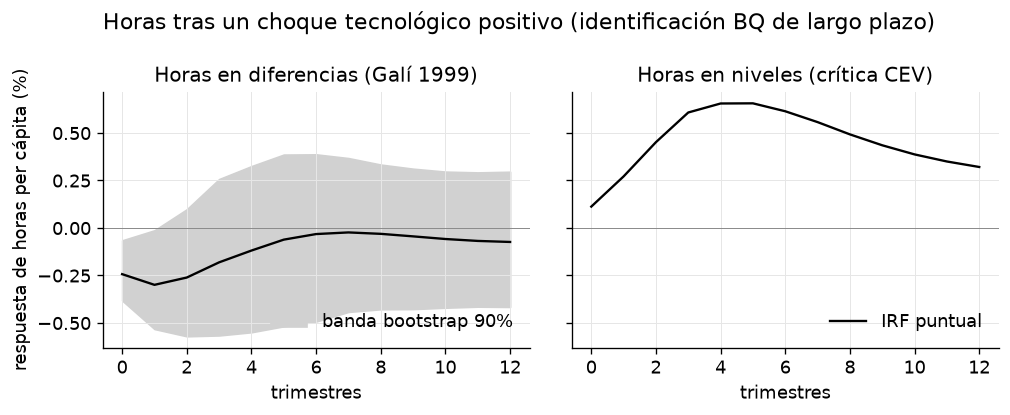

In [4]:
H = res_diff.irf_point.shape[0] - 1
hs = np.arange(H + 1)
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.5), sharey=True)

ax = axes[0]
ax.plot(hs, res_diff.irf_point[:, 1, 0], color="0.0", lw=1.4)
ax.fill_between(hs, res_diff.irf_lower[:, 1, 0], res_diff.irf_upper[:, 1, 0],
                color="0.82", label="banda bootstrap 90%")
ax.axhline(0.0, color="0.55", lw=0.6)
ax.set_title("Horas en diferencias (Galí 1999)")
ax.set_xlabel("trimestres"); ax.set_ylabel("respuesta de horas per cápita (%)")
ax.legend(loc="lower right")

ax = axes[1]
ax.plot(hs, raw_lvl[:, 1, 0], color="0.0", lw=1.4, label="IRF puntual")
ax.axhline(0.0, color="0.55", lw=0.6)
ax.set_title("Horas en niveles (crítica CEV)")
ax.set_xlabel("trimestres")
ax.legend(loc="lower right")

fig.suptitle("Horas tras un choque tecnológico positivo (identificación BQ de largo plazo)")
fig.tight_layout()
plt.show()

**Lectura.** Con las horas en **diferencias** (Galí), la respuesta de impacto es
**negativa** y la banda al 90% excluye el cero: las horas caen — el resultado
anti-RBC. Al medir las horas en **niveles** (CEV 2003), el signo se voltea. El
hallazgo empírico depende, entonces, de una decisión de **identificación**:
¿son las horas estacionarias en niveles o hay que diferenciarlas?

## 3. El largo plazo: estado estacionario y senda de crecimiento balanceado

Antes de resolver el modelo hay que saber **hacia dónde converge**. El mazo
distingue dos comportamientos de largo plazo:

- **Estado estacionario (ee)**: si $A_t=A$ y $N_t=N$, todas las variables se
  quedan quietas.
- **Senda de crecimiento balanceado (SCB)**: si $A_{t+1}=(1+\hat A)A_t$ y
  $N_{t+1}=(1+\hat N)N_t$, todas crecen a tasas constantes; $Y$, $C$, $K$ e $I$
  crecen a la misma tasa $g$, con
  $$ 1+g=(1+\hat A)^{\frac{1}{1-\alpha}}(1+\hat N). $$

En la SCB, la Euler de las variables sin tendencia lleva un factor $(1+g)$,
$(1+g)\frac{c'}{\beta c}=\alpha\frac{y'}{k'}+1-\delta$, de modo que
$$ \frac{k}{y}=\frac{\alpha}{\frac{1+g}{\beta}-1+\delta},\qquad
   s=\frac{i}{y}=(g+\delta)\frac{k}{y},\qquad
   l^{scb}=\frac{1-\alpha}{1-\alpha+\gamma\,(1-s)} $$
(con $n=1$, la normalización del mazo). El estado estacionario es el caso
$g=0$: $k/y=\alpha/(1/\beta-1+\delta)$ y $s=\delta\,k/y$.

In [5]:
def largo_plazo(alpha=0.33, beta=0.99, delta=0.025, gamma=1.75, g=0.0):
    """Razones de largo plazo (ee si g=0, SCB si g>0). n = 1."""
    ky = alpha / ((1.0 + g) / beta - 1.0 + delta)
    s = (g + delta) * ky                              # i/y = (g+delta)*k/y
    cy = 1.0 - s
    l = (1.0 - alpha) / (1.0 - alpha + gamma * (1.0 - s))
    return dict(ky=ky, s=s, cy=cy, l=l)

CAL = dict(alpha=0.33, beta=0.99, delta=0.025, gamma=1.75)   # trimestral, mazo A2
ee = largo_plazo(**CAL, g=0.0)
print("estado estacionario (calibración trimestral del mazo):")
print(f"  k/y = {ee['ky']:.4f}   (trimestres de producto)")
print(f"  c/y = {ee['cy']:.4f}   s = i/y = {ee['s']:.4f}   l_ss = {ee['l']:.4f}")

assert abs(ee["ky"] - 9.4) < 0.05 and abs(ee["cy"] - 0.765) < 0.005
assert abs(ee["l"] - 0.334) < 0.001                 # cifras del mazo A2

estado estacionario (calibración trimestral del mazo):
  k/y = 9.4014   (trimestres de producto)
  c/y = 0.7650   s = i/y = 0.2350   l_ss = 0.3336


### Coeficientes indeterminados: $(\psi_k,\psi_c,\psi_l)$

Log-linealizando y postulando reglas $\tilde k_t=\psi_k\tilde k_{t-1}$,
$\tilde l_t=\psi_l\tilde k_{t-1}$, $\tilde c_t=\psi_c\tilde k_{t-1}$, el mazo
llega a tres ecuaciones (con $n=1$ y $\theta\equiv(1-\alpha)\left[1-\frac{\beta(1-\delta)}{1+g}\right]$):
$$ \psi_c+\Big(\alpha+\tfrac{l}{1-l}\Big)\psi_l-\alpha=0, $$
$$ \psi_c(\psi_k-1)-\theta\,\psi_k(\psi_l-1)=0, $$
$$ \tfrac{c}{y}\psi_c+(1+g)\tfrac{k}{y}\psi_k-(1-\delta)\tfrac{k}{y}-\alpha-(1-\alpha)\psi_l=0. $$
La primera y la tercera son **lineales**: dejan $\psi_c$ y $\psi_k$ como
funciones afines de $\psi_l$, y al sustituirlas en la segunda queda una
**cuadrática en $\psi_l$** con dos raíces. La transversalidad se queda con la
que da $|\psi_k|<1$; la otra es explosiva.

In [6]:
def coeficientes(alpha=0.33, beta=0.99, delta=0.025, gamma=1.75, g=0.0):
    """Resuelve (psi_k, psi_c, psi_l) por coeficientes indeterminados."""
    lp = largo_plazo(alpha, beta, delta, gamma, g)
    ky, cy, l = lp["ky"], lp["cy"], lp["l"]
    D = alpha + l / (1.0 - l)                       # de la intratemporal
    th = (1.0 - alpha) * (1.0 - beta * (1.0 - delta) / (1.0 + g))
    a0 = ((1.0 - delta) * ky + alpha - cy * alpha) / ((1.0 + g) * ky)
    a1 = ((1.0 - alpha) + cy * D) / ((1.0 + g) * ky)   # psi_k = a0 + a1*psi_l
    # psi_c = alpha - D*psi_l  ->  (alpha - D*pl)(a0-1+a1*pl) - th*(a0+a1*pl)(pl-1) = 0
    q = [-D * a1 - th * a1,
         alpha * a1 - D * (a0 - 1.0) - th * a0 + th * a1,
         alpha * (a0 - 1.0) + th * a0]
    sol = []
    for pl in np.real(np.roots(q)):
        pc, pk = alpha - D * pl, a0 + a1 * pl
        sol.append((float(pk), float(pc), float(pl)))
    estable = [t for t in sol if abs(t[0]) < 1.0]
    inestable = [t for t in sol if abs(t[0]) >= 1.0]
    return estable[0], inestable[0], lp, th

(psi_k, psi_c, psi_l), inest, lp0, th0 = coeficientes(**CAL, g=0.0)
# Verificación: las TRES ecuaciones del mazo evaluadas en la solución.
r1 = psi_c + (CAL["alpha"] + lp0["l"] / (1 - lp0["l"])) * psi_l - CAL["alpha"]
r2 = psi_c * (psi_k - 1) - th0 * psi_k * (psi_l - 1)
r3 = (lp0["cy"] * psi_c + lp0["ky"] * psi_k - (1 - CAL["delta"]) * lp0["ky"]
      - CAL["alpha"] - (1 - CAL["alpha"]) * psi_l)

print(f"raíz estable:   psi_k = {psi_k:.5f}  psi_c = {psi_c:.5f}  psi_l = {psi_l:.5f}")
print(f"raíz explosiva: psi_k = {inest[0]:.5f}  (descartada por transversalidad)")
print(f"residuos de las tres ecuaciones: {abs(r1):.1e}, {abs(r2):.1e}, {abs(r3):.1e}")
print(f"vida media del capital: {np.log(0.5)/np.log(psi_k):.1f} trimestres")

assert max(abs(r1), abs(r2), abs(r3)) < 1e-10
assert abs(psi_k - 0.949) < 5e-4 and abs(psi_c - 0.537) < 5e-4
assert abs(psi_l + 0.249) < 5e-4                    # cifras del mazo A2
assert abs(inest[0] - 1.065) < 5e-4

raíz estable:   psi_k = 0.94862  psi_c = 0.53712  psi_l = -0.24939
raíz explosiva: psi_k = 1.06481  (descartada por transversalidad)
residuos de las tres ecuaciones: 5.6e-17, 3.5e-18, 1.3e-15
vida media del capital: 13.1 trimestres


### ¿Qué cambia al pasar del estado estacionario a la SCB?

**Solo los términos con $(1+g)$**: $\beta(1-\delta)$ se vuelve
$\beta(1-\delta)/(1+g)$ y $k/y$ se multiplica por $(1+g)$. Con crecimiento del
producto per cápita de **2% anual** y población al **1% anual** (calibración
ilustrativa), $1+g=(1+\hat A)^{1/(1-\alpha)}(1+\hat N)$ da un $g$ trimestral
de tres cuartos de punto — y el capital converge algo **más rápido** (la SCB ya
se está llevando parte del ajuste).

In [7]:
g_pc = 1.02 ** 0.25 - 1.0                        # producto per cápita, trimestral
n_hat = 1.01 ** 0.25 - 1.0                       # población, trimestral
g = (1.0 + g_pc) * (1.0 + n_hat) - 1.0           # = (1+A_hat)^{1/(1-alpha)}(1+N_hat) - 1
A_hat = (1.0 + g_pc) ** (1.0 - CAL["alpha"]) - 1.0

(pk_g, pc_g, pl_g), _, lp_g, _ = coeficientes(**CAL, g=g)
print(f"g = {100*g:.4f}% trimestral   (A_hat = {100*A_hat:.4f}%, N_hat = {100*n_hat:.4f}%)")
print(f"  ee : k/y = {lp0['ky']:.3f}  s = {lp0['s']:.4f}  l = {lp0['l']:.4f}  psi_k = {psi_k:.4f}")
print(f"  SCB: k/y = {lp_g['ky']:.3f}  s = {lp_g['s']:.4f}  l = {lp_g['l']:.4f}  psi_k = {pk_g:.4f}")

assert lp_g["ky"] < lp0["ky"]        # descontar el futuro más fuerte reduce k/y
assert lp_g["s"] > lp0["s"]          # hay que reponer depreciación Y crecimiento
assert pk_g < psi_k                  # convergencia más rápida en la SCB

g = 0.7466% trimestral   (A_hat = 0.3322%, N_hat = 0.2491%)
  ee : k/y = 9.401  s = 0.2350  l = 0.3336  psi_k = 0.9486
  SCB: k/y = 7.739  s = 0.2512  l = 0.3383  psi_k = 0.9385


## 4. Resolviendo el modelo: iteración de la función de valor

El corazón del modelo neoclásico es un problema de programación dinámica. Con
**depreciación total** ($\delta=1$), utilidad logarítmica y tecnología
Cobb–Douglas obtenemos el caso clásico de **Brock–Mirman (1972)**, que tiene
**solución exacta** — el laboratorio perfecto para validar un solucionador.

**Planificador (determinista):** con $A=1$ y $g=0$, consumo
$c = k^{\alpha} - k'$ y utilidad $u(c)=\log c$. La ecuación de Bellman:
$$ V(k) = \max_{k'}\ \log\big(k^{\alpha} - k'\big) + \beta\,V(k'). $$

**Solución exacta.** La política es $k' = \alpha\beta A\,k^{\alpha}$ —aquí
$k'=\alpha\beta\,k^{\alpha}$— y la función de valor es
$$ v(k) = \underbrace{\frac{\log(1-\alpha\beta) + \tfrac{\alpha\beta}{1-\alpha\beta}\,\log(\alpha\beta)}{1-\beta}}_{\text{cte}}
         + \frac{\alpha}{1-\alpha\beta}\,\log k. $$
Nota que la **renta del capital** $\alpha$ fija tanto la pendiente en $\log k$
como la fracción de la producción que se ahorra ($\alpha\beta$).

> **Ojo con la calibración.** Esta sección usa la del *ejercicio* del mazo
> ($\alpha=0.33$, $\beta=0.97$, $\delta=1$), que **no** es la trimestral de la
> sección 3 ($\beta=0.99$, $\delta=0.025$). El $\delta=1$ es lo que compra la
> solución exacta, y a cambio obliga a leer el periodo como algo más largo que
> un trimestre.

### Bellman es una contracción

El operador de Bellman $T$ es una **contracción de módulo $\beta$** en la
norma del supremo (Blackwell). Por tanto, partiendo de cualquier $V_0$,
$$ \lVert V_n - v\rVert_\infty \le \beta^{\,n}\,\lVert V_0 - v\rVert_\infty. $$
En escala logarítmica el error cae en **línea recta con pendiente $\log\beta$**,
hasta que topa con el **piso de discretización** de la malla. Lo verificamos
midiendo, en cada iteración, la distancia sup-norma entre la $V$ numérica y la
solución exacta $v(k)$. Todo en **NumPy puro**.

In [8]:
alpha, beta = 0.33, 0.97               # calibración del ejercicio del mazo A2
v_pend = alpha / (1.0 - alpha * beta)  # pendiente exacta en log k
v_cte = (np.log(1.0 - alpha * beta)
         + beta * v_pend * np.log(alpha * beta)) / (1.0 - beta)

def v_exact(kk):
    return v_cte + v_pend * np.log(kk)

k_ss = (alpha * beta) ** (1.0 / (1.0 - alpha))        # punto fijo de k'=alpha*beta*k^alpha
k = np.linspace(0.4 * k_ss, 2.2 * k_ss, 600)          # malla de capital
Y = k ** alpha
C = Y[:, None] - k[None, :]                           # C[i,j] = k_i^alpha - k'_j
with np.errstate(divide="ignore", invalid="ignore"):
    U = np.where(C > 0.0, np.log(C), -np.inf)         # utilidad; -inf donde c<=0

ve = v_exact(k)
interior = (k > 0.5 * k_ss) & (k < 2.0 * k_ss)        # evita bordes de malla al comparar

V = np.zeros_like(k)
errors = []
for it in range(600):
    Q = U + beta * V[None, :]                         # T(V): valor de cada k' para cada k
    V_new = Q.max(axis=1)                             # max sobre k'
    errors.append(float(np.max(np.abs(V_new - ve)[interior])))
    V = V_new
errors = np.array(errors)

policy = k[Q.argmax(axis=1)]                          # política numérica k'(k)
policy_closed = alpha * beta * k ** alpha             # forma cerrada Brock–Mirman

### La recta de pendiente $\log\beta$

Ajustamos una recta al tramo geométrico del error (antes del piso de
discretización): su pendiente debe coincidir con $\log_{10}\beta$.

In [9]:
floor = errors[-1]                                    # piso de discretización de la malla
seg = np.where((errors > 20.0 * floor) & (np.arange(len(errors)) > 2))[0]
slope = np.polyfit(seg, np.log10(errors[seg]), 1)[0]  # pendiente ajustada (log10 por iteración)

print(f"k* (estado estacionario con delta=1): {k_ss:.4f}")   # el 'k*=0.183' del mazo
print(f"error final (piso de discretización): {floor:.2e}")
print(f"pendiente ajustada (log10/iter): {slope:.5f}")
print(f"log10(beta):                     {np.log10(beta):.5f}")
print(f"razón pendiente/log10(beta):     {slope/np.log10(beta):.4f}")
print(f"error máx. de política vs Brock–Mirman (interior): "
      f"{np.max(np.abs(policy - policy_closed)[interior]):.2e}")

assert errors[5] < errors[0]                          # el error decae
assert abs(slope / np.log10(beta) - 1.0) < 0.05       # pendiente ~ log(beta)
assert np.max(np.abs(policy - policy_closed)[interior]) < 1e-2  # política ~ forma cerrada

k* (estado estacionario con delta=1): 0.1827
error final (piso de discretización): 7.33e-06
pendiente ajustada (log10/iter): -0.01324
log10(beta):                     -0.01323
razón pendiente/log10(beta):     1.0010
error máx. de política vs Brock–Mirman (interior): 3.41e-04


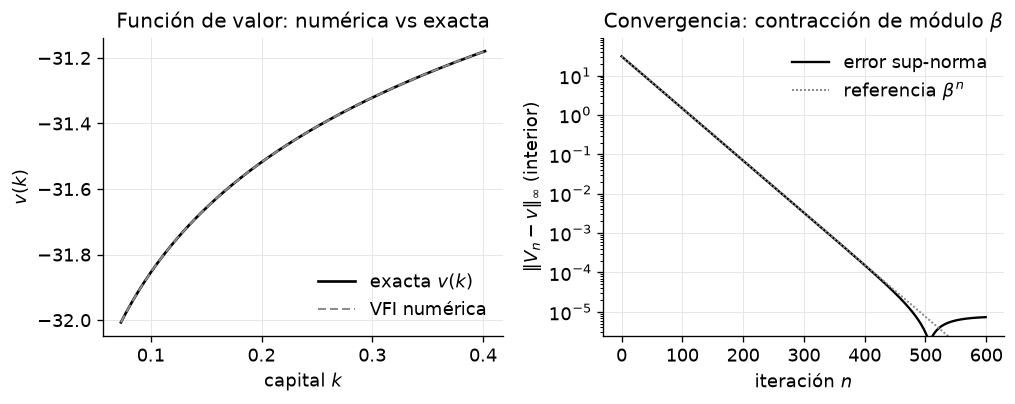

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.5))

ax = axes[0]
ax.plot(k, ve, color="0.0", lw=1.6, label="exacta $v(k)$")
ax.plot(k, V, color="0.55", lw=1.2, ls=(0, (4, 2)), label="VFI numérica")
ax.set_title("Función de valor: numérica vs exacta")
ax.set_xlabel("capital $k$"); ax.set_ylabel("$v(k)$")
ax.legend(loc="lower right")

ax = axes[1]
it = np.arange(len(errors))
ax.semilogy(it, errors, color="0.0", lw=1.4, label="error sup-norma")
ref = errors[seg[0]] * beta ** (it - seg[0])          # recta de referencia, pendiente log(beta)
ax.semilogy(it, ref, color="0.55", lw=1.2, ls=(0, (1, 1)), label=r"referencia $\beta^{n}$")
ax.set_ylim(floor / 3, errors[0] * 3)
ax.set_title("Convergencia: contracción de módulo $\\beta$")
ax.set_xlabel("iteración $n$"); ax.set_ylabel(r"$\|V_n - v\|_\infty$ (interior)")
ax.legend(loc="upper right")

fig.tight_layout()
plt.show()

**Lectura.** La $V$ numérica se pega a la exacta, y el error sup-norma cae en
línea recta (escala log) con pendiente $\log\beta$ hasta el piso que impone la
malla. La política numérica reproduce la forma cerrada $k'=\alpha\beta\,k^{\alpha}$.
VFI **funciona** y sabemos *exactamente* qué tan rápido converge.

## 5. Laboratorio práctico
- `puremacro.dsge.klein_solve` (QZ, Klein 2000) resuelve por otra vía el mismo
  sistema log-linealizado de la sección 3: buen contraste independiente para
  $(\psi_k,\psi_c,\psi_l)$.
- `puremacro.vfi.neoclassical_growth(...)` resuelve la versión **estocástica**
  (TFP AR(1), CRRA, depreciación parcial) por VFI y devuelve `'solution'`
  (política), `'distribution'` (medida ergódica) y `'mean_capital'`.
- El caso de validación `vfi.neoclassical_brock_mirman_policy` en
  `puremacro.validation.cases_vfi` compara, automáticamente, la política de VFI
  con la forma cerrada de Brock–Mirman — la misma prueba que hicimos a mano.

## 6. Preguntas para pensar
1. **Modelo vs. identificación.** Si en la especificación en **niveles** las
   horas *suben* tras el choque tecnológico (CEV 2003), ¿qué falla: el modelo
   RBC o la identificación de Galí? ¿Cómo distinguirías empíricamente entre
   "las horas son estacionarias en niveles" y "las horas tienen raíz unitaria"?
2. **Velocidad de convergencia.** Si subes $\beta$ de 0.97 a 0.99, ¿la VFI
   converge más rápido o más lento? Predice el cambio de pendiente antes de
   correrlo.
3. **Piso de discretización.** Al duplicar el número de nodos de la malla, ¿qué
   parte del gráfico de convergencia cambia: la pendiente o el piso? ¿Por qué?
4. **SCB.** En la sección 3, pasar del estado estacionario a la SCB *baja*
   $k/y$ y *sube* la tasa de ahorro $s$. ¿Por qué las dos cosas a la vez, si
   hay menos capital por unidad de producto?

### Notas para las preguntas
1. Ambas cosas están entrelazadas: el resultado "las horas caen" es correcto
   *condicional* a diferenciar las horas; en niveles se atenúa o voltea. La
   literatura post-Galí discute si las horas tienen raíz unitaria (pruebas de
   raíz unitaria de baja potencia) — de ahí que la evidencia no sea concluyente.
2. Un $\beta$ mayor → contracción más lenta (pendiente $\log\beta$ más plana,
   más cerca de 0) → más iteraciones para converger.
3. Cambia el **piso** (la malla más fina reduce el error de discretización); la
   **pendiente** sigue siendo $\log\beta$ (es propiedad del operador, no de la malla).
4. Son dos márgenes distintos. $k/y=\alpha/[(1+g)/\beta-1+\delta]$ cae porque
   con crecimiento el hogar descuenta más fuerte el futuro (la Euler lleva
   $(1+g)$). Y $s=(g+\delta)k/y$ sube porque ahora la inversión no solo repone
   la depreciación $\delta$: también tiene que **dotar de capital al
   crecimiento** $g$, y ese segundo efecto domina a la caída de $k/y$.

## 7. Explora con IA
Prueba esto con el tutor sin conexión (o cualquier asistente de IA):
- "¿Por qué la restricción de largo plazo de Blanchard–Quah identifica el choque tecnológico?"
- "Explica en una frase por qué el operador de Bellman es una contracción de módulo beta."

In [11]:
print(tutor("En una frase, ¿por qué el operador de Bellman es una contracción de módulo beta?"))

[tutor sin conexión] No hay ningún motor de LLM local disponible en esta instalación (el tutor es opcional). Puedes instalar uno con `pip install puremacro[local-llm]` más un modelo pequeño (por ejemplo vía Ollama o MLX), o bien usar las indicaciones de la sección «Explora con IA» de esta lección con cualquier asistente de IA.
(motivo: el motor local no está disponible)


**Resumen.** Pusimos a prueba el modelo neoclásico por los tres lados. En lo
**empírico**, la identificación de largo plazo de Blanchard–Quah replica a Galí
(1999): las horas caen ante un choque tecnológico — pero el signo depende de
diferencias vs. niveles (crítica CEV 2003). En lo **analítico**, calculamos el
largo plazo —estado estacionario y **SCB**— y resolvimos los coeficientes
indeterminados $(\psi_k,\psi_c,\psi_l)=(0.949,\,0.537,\,-0.249)$, las mismas
cifras del mazo. En lo **numérico**, resolvimos el modelo por iteración de la
función de valor y lo validamos contra la solución exacta de Brock–Mirman
($\delta=1$): el error cae a tasa $\log\beta$ hasta el piso de la malla. Todo en
`puremacro` (Python puro), ejecutable sin conexión en tu propia máquina.

**Siguiente módulo:** la lección **03 — riesgo e incertidumbre**
(`03_riesgo_incertidumbre_es`), que es el bloque de la semana 5 (mazo Slides03) y el
último antes del primer examen parcial.